In [1]:
import pandas as pd
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:/Python/Datasets/WA_Marketing-Campaign.csv')
df

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81
...,...,...,...,...,...,...,...
543,10,Large,919,2,1,4,64.34
544,10,Large,920,14,2,1,50.20
545,10,Large,920,14,2,2,45.75
546,10,Large,920,14,2,3,44.29


In [3]:
df.Promotion.value_counts()

Promotion
3    188
2    188
1    172
Name: count, dtype: int64

In [4]:
df.MarketSize.value_counts()

MarketSize
Medium    320
Large     168
Small      60
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


In [6]:
def check_df(dataframe, head = 5):
    print("############## Shape ##############")
    print(dataframe.shape)
    print("############## Types ##############")
    print(dataframe.dtypes)
    print("############## Head ##############")
    print(dataframe.head(head))
    print("############## Tail ##############")
    print(dataframe.tail(head))
    print("############## NA ##############")
    print(dataframe.isnull().sum())
    print("############## Quantiles ##############")
    print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

check_df(df)

############## Shape ##############
(548, 7)
############## Types ##############
MarketID              int64
MarketSize           object
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object
############## Head ##############
   MarketID MarketSize  LocationID  AgeOfStore  Promotion  week  \
0         1     Medium           1           4          3     1   
1         1     Medium           1           4          3     2   
2         1     Medium           1           4          3     3   
3         1     Medium           1           4          3     4   
4         1     Medium           2           5          2     1   

   SalesInThousands  
0             33.73  
1             35.67  
2             29.03  
3             39.25  
4             27.81  
############## Tail ##############
     MarketID MarketSize  LocationID  AgeOfStore  Promotion  week  \
543        10      Large         91

In [7]:
df.groupby(by='Promotion', as_index=False).agg({'SalesInThousands':['mean', 'sum', 'count']})

Promotion SalesInThousands                
                        mean       sum count
0         1        58.099012   9993.03   172
1         2        47.329415   8897.93   188
2         3        55.364468  10408.52   188

In [8]:
df.groupby(by=['Promotion', 'MarketSize'], as_index=False).agg({'SalesInThousands':['mean', 'sum', 'count']})

Promotion MarketSize SalesInThousands               
                                   mean      sum count
0         1      Large        75.235893  4213.21    56
1         1     Medium        47.672604  4576.57    96
2         1      Small        60.162500  1203.25    20
3         2      Large        60.322031  3860.61    64
4         2     Medium        39.114352  4224.35   108
5         2      Small        50.810625   812.97    16
6         3      Large        77.203958  3705.79    48
7         3     Medium        45.468879  5274.39   116
8         3      Small        59.514167  1428.34    24

<Axes: xlabel='SalesInThousands'>

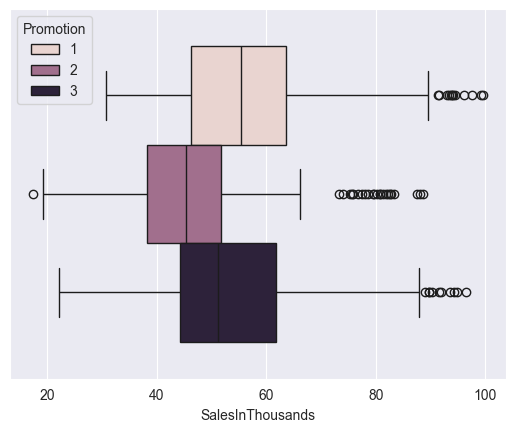

In [9]:
sns.set_style('darkgrid')
sns.boxplot(data=df, x='SalesInThousands', hue='Promotion')

Shapiro-Wilk test for normal distribution

In [10]:
for group in list(df["Promotion"].unique()):
    pvalue = sts.shapiro(df.loc[df["Promotion"] == group, "SalesInThousands"])[1]
    print(group, 'p-value: %.4f' % pvalue)

3 p-value: 0.0000
2 p-value: 0.0000
1 p-value: 0.0000


Normal distribution is not met

Levene Test for homogenity

In [11]:
test_stat, pvalue = sts.levene(df.loc[df['Promotion'] == 1, "SalesInThousands"],
                           df.loc[df['Promotion'] == 2, "SalesInThousands"],
                           df.loc[df['Promotion'] == 3, "SalesInThousands"])
print('Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))

Test Stat = 1.2697, p-value = 0.2818


Homogenity is met

Kruskal test is a non-parametrical test, is used when normal distribution is not met and there are 3+ groups to 

In [12]:
test_stat, pvalue = sts.kruskal(df.loc[df['Promotion'] == 1, "SalesInThousands"],
                            df.loc[df['Promotion'] == 2, "SalesInThousands"],
                            df.loc[df['Promotion'] == 3, "SalesInThousands"])

print("pvalue: ", "%.3f" % pvalue)

pvalue:  0.000


In [13]:
from statsmodels.stats.multicomp import MultiComparison

In [14]:
comparison = MultiComparison(df["SalesInThousands"], df["Promotion"])
tukey = comparison.tukeyhsd(0.05)
print(tukey.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


In [15]:
result = comparison.tukeyhsd()

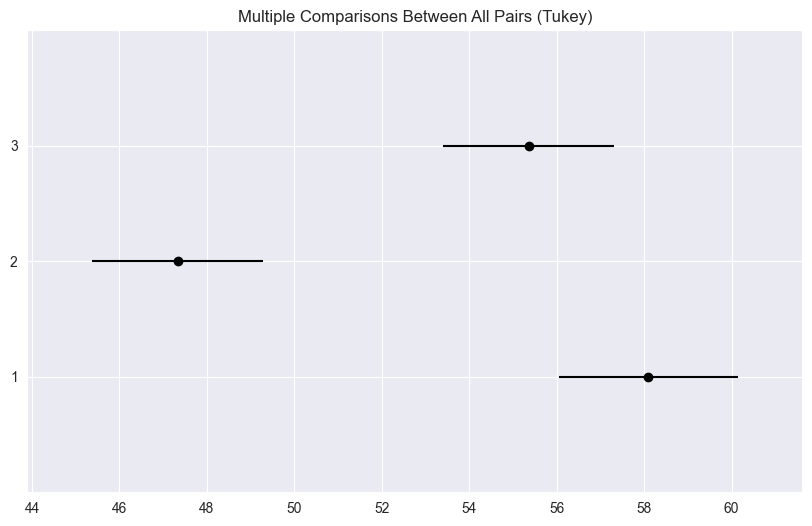

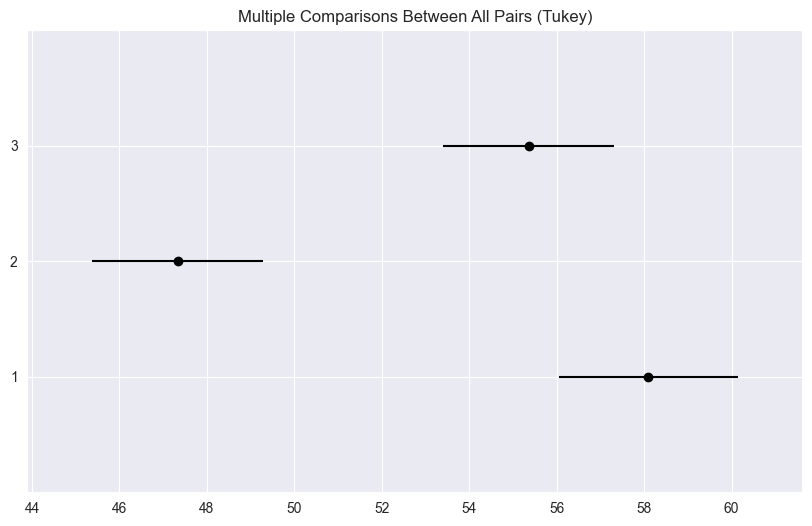

In [16]:
result.plot_simultaneous()

<Axes: xlabel='SalesInThousands', ylabel='Density'>

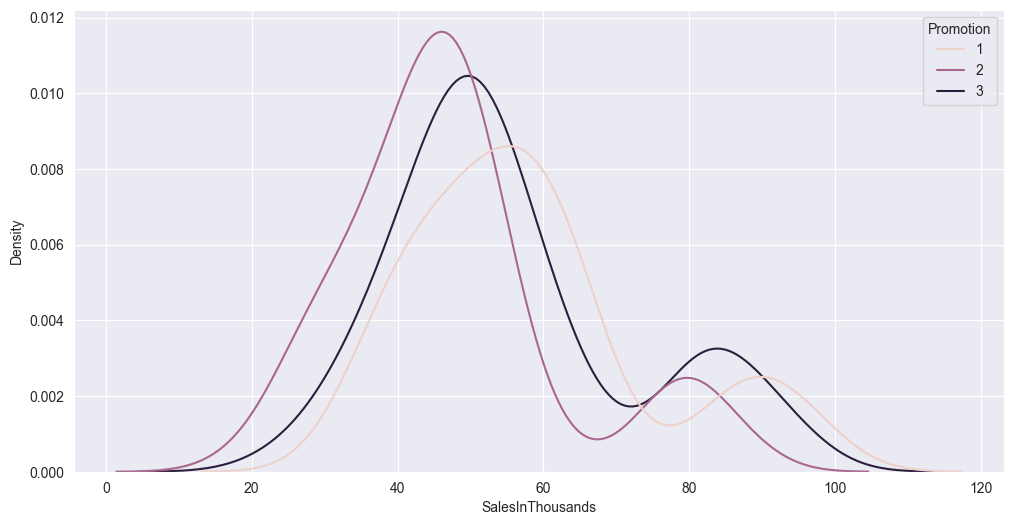

In [17]:
plt.subplots(figsize=(12,6))
sns.kdeplot(df, x='SalesInThousands', hue='Promotion')

In [18]:
sts.f_oneway(df.loc[df['Promotion'] == 1, "SalesInThousands"],
                            df.loc[df['Promotion'] == 2, "SalesInThousands"],
                            df.loc[df['Promotion'] == 3, "SalesInThousands"])

F_onewayResult(statistic=np.float64(21.953485793080674), pvalue=np.float64(6.765849261408834e-10))